In [1]:
list.of.packages <- c("tidyverse","ggfixest","stargazer","ggplot2","patchwork","data.table","broom")
new.packages <- list.of.packages[!(list.of.packages %in% installed.packages()[,"Package"])]
if(length(new.packages)) install.packages(new.packages, repos = "http://cran.us.r-project.org")

invisible(lapply(list.of.packages, library, character.only = TRUE))

options(repr.matrix.max.rows=500, repr.matrix.max.cols=500)  

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Le chargement a nécessité le package : fixest


Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary Statistics Tables.

 R package version 5.2.3. https://CRAN.R-project.org/package=stargazer 



Attachement du package : ‘data.table’


Les objets suivants sont masqués depuis ‘package:lubridate’:

    hour, isoweek, mday, minute, month, 

In [2]:
T_bins_labels <- c("<=17°C","17,21]","21,23]","23,25]","25,27]","27,29]","29,31]","31,33]",">33°C")
T_bins_labels_pretty <- c("≤17°C", "(17,21]", "(21,23]", "(23,25]", "(25,27]", "(27,29]", "(29,31]", "(31,33]", ">33°C")

bin_ref_T <-"17,21]"

varT <- "T_i30_bin"
dict <- setNames(paste0("Air T: ",T_bins_labels_pretty), paste0(varT, "::", T_bins_labels))

# Men

In [3]:
df_men <- fread("./2_Regression_datasets/output/df_reg_men.csv")
sprintf("%i rows x %i columns", nrow(df_men), ncol(df_men))
head(df_men,2)

[1] "150101 rows x 330 columns"

DHS_round,DHSCLUST,State_2011,District_2011,cell_x_01,cell_y_01,cell_x_025,cell_y_025,HH_ID,Men_id,Resp_nb,Interview_month,Interview_year,Interview_day,Measured_date_CDC,Measured_date,Current_age,Age_group,Religion_hindu,Religion_muslim,Religion_not_hindu_nor_muslim,Ethni_SC,Ethni_ST,Ethni_OBC,Ethni_other,N_year_educ,Smoker,Health_insurance,Profession,Blood_pressure_systo,Blood_pressure_diasto,Blood_glucose_level,Diet_milk_curd_daily,Diet_milk_curd_week,Diet_milk_curd_oc,Diet_milk_curd_never,Diet_pulses_beans_daily,Diet_pulses_beans_week,Diet_pulses_beans_oc,Diet_pulses_beans_never,Diet_green_veg_daily,Diet_green_veg_week,Diet_green_veg_oc,Diet_green_veg_never,Diet_fruits_daily,Diet_fruits_week,Diet_fruits_oc,Diet_fruits_never,Diet_eggs_daily,Diet_eggs_week,Diet_eggs_oc,Diet_eggs_never,Diet_fish_daily,Diet_fish_week,Diet_fish_oc,Diet_fish_never,Diet_chicken_meat_daily,Diet_chicken_meat_week,Diet_chicken_meat_oc,Diet_chicken_meat_never,Diet_fried_food_daily,Diet_fried_food_week,Diet_fried_food_oc,Diet_fried_food_never,Diet_aerated_drinks_daily,Diet_aerated_drinks_week,Diet_aerated_drinks_oc,Diet_aerated_drinks_never,Wealth_lowest,Wealth_second,Wealth_middle,Wealth_fourth,Wealth_highest,Urban,Usual_resident,Blood_hemo_level_alti,Body_mass_index,Bednet_slept,HH_time_water_source,HH_air_conditioner,HH_treat_water,HH_no_toilet,HH_well_water,cell_x.x,cell_y.x,cell_x.y,cell_y.y,Measured_month,Measured_year,Men_anemia,Men_severe_anemia,Men_moderate_anemia,Men_mild_anemia,Men_no_anemia,BMI_category,Blood_hypertension,Water_fetching_risk,District_ID,T_i30,T_i20,T_i10,T_i30_bin,T_i20_bin,T_i10_bin,T_Bin_17_21_Nhours_on30,T_Bin_21_23_Nhours_on30,T_Bin_23_25_Nhours_on30,T_Bin_25_27_Nhours_on30,T_Bin_27_29_Nhours_on30,T_Bin_29_31_Nhours_on30,T_Bin_inf17_Nhours_on30,T_Bin_31_33_Nhours_on30,T_Bin_sup33_Nhours_on30,T_Bin_17_21_Nhours_on20,T_Bin_21_23_Nhours_on20,T_Bin_23_25_Nhours_on20,T_Bin_25_27_Nhours_on20,T_Bin_27_29_Nhours_on20,T_Bin_29_31_Nhours_on20,T_Bin_inf17_Nhours_on20,T_Bin_31_33_Nhours_on20,T_Bin_sup33_Nhours_on20,T_Bin_17_21_Nhours_on10,T_Bin_21_23_Nhours_on10,T_Bin_23_25_Nhours_on10,T_Bin_25_27_Nhours_on10,T_Bin_27_29_Nhours_on10,T_Bin_29_31_Nhours_on10,T_Bin_inf17_Nhours_on10,T_Bin_31_33_Nhours_on10,T_Bin_sup33_Nhours_on10,T_MeanBin_23_25_Ndays_on30,T_MeanBin_21_23_Ndays_on30,T_MeanBin_25_27_Ndays_on30,T_MeanBin_inf17_Ndays_on30,T_MeanBin_17_21_Ndays_on30,T_MeanBin_27_29_Ndays_on30,T_MeanBin_29_31_Ndays_on30,T_MeanBin_31_33_Ndays_on30,T_MeanBin_sup33_Ndays_on30,T_MeanBin_23_25_Ndays_on20,T_MeanBin_21_23_Ndays_on20,T_MeanBin_25_27_Ndays_on20,T_MeanBin_inf17_Ndays_on20,T_MeanBin_17_21_Ndays_on20,T_MeanBin_27_29_Ndays_on20,T_MeanBin_29_31_Ndays_on20,T_MeanBin_31_33_Ndays_on20,T_MeanBin_sup33_Ndays_on20,T_MeanBin_23_25_Ndays_on10,T_MeanBin_21_23_Ndays_on10,T_MeanBin_25_27_Ndays_on10,T_MeanBin_inf17_Ndays_on10,T_MeanBin_17_21_Ndays_on10,T_MeanBin_27_29_Ndays_on10,T_MeanBin_29_31_Ndays_on10,T_MeanBin_31_33_Ndays_on10,T_MeanBin_sup33_Ndays_on10,T_MinBin_17_19_Ndays_on30,T_MinBin_15_17_Ndays_on30,T_MinBin_19_21_Ndays_on30,T_MinBin_21_23_Ndays_on30,T_MinBin_inf11_Ndays_on30,T_MinBin_11_13_Ndays_on30,T_MinBin_13_15_Ndays_on30,T_MinBin_23_25_Ndays_on30,T_MinBin_sup25_Ndays_on30,T_MinBin_17_19_Ndays_on20,T_MinBin_15_17_Ndays_on20,T_MinBin_19_21_Ndays_on20,T_MinBin_21_23_Ndays_on20,T_MinBin_inf11_Ndays_on20,T_MinBin_11_13_Ndays_on20,T_MinBin_13_15_Ndays_on20,T_MinBin_23_25_Ndays_on20,T_MinBin_sup25_Ndays_on20,T_MinBin_17_19_Ndays_on10,T_MinBin_15_17_Ndays_on10,T_MinBin_19_21_Ndays_on10,T_MinBin_21_23_Ndays_on10,T_MinBin_inf11_Ndays_on10,T_MinBin_11_13_Ndays_on10,T_MinBin_13_15_Ndays_on10,T_MinBin_23_25_Ndays_on10,T_MinBin_sup25_Ndays_on10,T_MaxBin_29_31_Ndays_on30,T_MaxBin_31_33_Ndays_on30,T_MaxBin_27_29_Ndays_on30,T_MaxBin_25_27_Ndays_on30,T_MaxBin_23_25_Ndays_on30,T_MaxBin_inf21_Ndays_on30,T_MaxBin_21_23_Ndays_on30,T_MaxBin_33_35_Ndays_on30,T_MaxBin_sup35_Ndays_on30,T_MaxBin_29_31_Ndays_on20,T_MaxBin_31_33_Ndays_on20,T_MaxBin_27_29_Ndays_

In [4]:
df_reg_men <- df_men %>%
                mutate(T_i30_bin=factor(gsub("\\(","",T_i30_bin),levels=T_bins_labels)
)

In [5]:
df_reg_men %>% group_by(Profession)%>%summarize(N=n())

Profession,N
<chr>,<int>
agri,46375
clerical,2647
manual,36213
no_work,31144
prof_tech_manag,8327
sales,12753
services,10028
NA,2614


# Hemoglobin level

## Temperature reg

In [6]:
reg_men_T <- feols(Blood_hemo_level_alti ~ Profession + i(T_i30_bin,Profession,ref=bin_ref_T) + P_tot_30 + 
                                        Current_age + N_year_educ + 
                                        Smoker + Health_insurance + 
                                        Religion_muslim + Religion_not_hindu_nor_muslim + 
                                        Ethni_SC + Ethni_ST + Ethni_OBC +
                                        Wealth_lowest + Wealth_second + Wealth_fourth + Wealth_highest + 
                                        Urban
                                        |District_ID^Measured_month + District_ID^Measured_year,
                    vcov = ~District_ID,
                    df_reg_men)

NOTES: 11,910 observations removed because of NA values (RHS: 11,910).
       14/1 fixed-effect singletons were removed (14 observations).



In [7]:
etable(reg_men_T,
       tex=TRUE,
       fitstat = ~ n + r2 + my,
       drop="%!_bin|agri",
       dict=dict)

\begingroup
\centering
\begin{tabular}{lc}
   \tabularnewline \midrule \midrule
   Dependent Variable:                                         & Blood\_hemo\_level\_alti\\     
   Model:                                                      & (1)\\  
   \midrule
   \emph{Variables}\\
   Air T: ≤17°C $\times$ Profession $=$ agri                   & -0.0077\\   
                                                               & (0.6973)\\   
   Air T: ≤17°C $\times$ Profession $=$ clerical               & 0.1559\\   
                                                               & (1.724)\\   
   Air T: ≤17°C $\times$ Profession $=$ manual                 & -0.6072\\   
                                                               & (0.8619)\\   
   Air T: ≤17°C $\times$ Profession $=$ no\_work               & -1.070\\   
                                                               & (0.6523)\\   
   Air T: ≤17°C $\times$ Profession $=$ prof\_tech\_manag      & -1.848$^{*}$\\   
        

# Extract coefs

In [8]:
occup_list <- c("agri","clerical","manual","no_work","prof_tech_manag","sales","services")

In [9]:
extract_estimate <- function(df,group_name,occup_name,Tbin_name){
            row <- tidy(df,conf.int=TRUE)%>%
                         filter(grepl(Tbin_name,term)&grepl(occup_name,term))%>% 
                         mutate(occupation = occup_name, 
                                group = group_name,
                                Tbin = Tbin_name)
            return(row)
}

In [10]:
men_estimates <- data.frame()
for (occup_name in occup_list){
    for (Tbin_name in T_bins_labels){
        row_estimate <- extract_estimate(reg_men_T,"Men",occup_name,Tbin_name)
        men_estimates <- rbind(men_estimates,row_estimate)
        }
    }

In [11]:
all_estimates <- men_estimates %>%
                   mutate(Tbin=factor(Tbin,levels=T_bins_labels),
                          occupation=factor(occupation,levels=c("agri","manual","sales","services","prof_tech_manag","clerical","no_work")))
all_estimates

term,estimate,std.error,statistic,p.value,conf.low,conf.high,occupation,group,Tbin
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>,<fct>
T_i30_bin::<=17°C:Profession::agri,-0.007723063,0.6972997,-0.01107567,9.911665e-01,-1.376999,1.3615529,agri,Men,<=17°C
"T_i30_bin::21,23]:Profession::agri",-1.800832083,0.5894727,-3.05498819,2.344415e-03,-2.958370,-0.6432944,agri,Men,"21,23]"
"T_i30_bin::23,25]:Profession::agri",-2.197204230,0.7209808,-3.04752097,2.402586e-03,-3.612982,-0.7814261,agri,Men,"23,25]"
"T_i30_bin::25,27]:Profession::agri",-3.327591878,0.8041436,-4.13805677,3.971604e-05,-4.906675,-1.7485084,agri,Men,"25,27]"
"T_i30_bin::27,29]:Profession::agri",-3.142722220,0.9075259,-3.46295581,5.699502e-04,-4.924816,-1.3606286,agri,Men,"27,29]"
"T_i30_bin::29,31]:Profession::agri",-3.741921510,1.0251239,-3.65021382,2.834435e-04,-5.754940,-1.7289027,agri,Men,"29,31]"
"T_i30_bin::31,33]:Profession::agri",-2.652776651,1.1275455,-2.35270039,1.893991e-02,-4.866919,-0.4386344,agri,Men,"31,33]"
T_i30_bin::>33°C:Profession::agri,-3.153751272,1.4380631,-2.19305479,2.866310e-02,-5.977652,-0.3298506,agri,Men,>33°C
T_i30_bin::<=17°C:Profession::clerical,0.155883256,1.7243875,0.09039921,9.279983e-01,-3.230268,3.5420342,clerical,Men,<=17°C


# Plot

In [12]:
theme_perso <- function(...){
                          theme(plot.title = element_text(size = 30, face="bold",hjust=0.5),
                                plot.subtitle = element_text(size = 28),
                                legend.position="none",
                                legend.title = element_text(size = 28,face ="bold"),
                                legend.text = element_text(size = 28),
                                strip.text.x = element_text(size = 28),
                                axis.text.x = element_text(size = 18,angle=45,hjust=1),
                                axis.text.y = element_text(size = 18),
                                axis.title.x = element_text(size = 20, hjust = 0.5),
                                axis.title.y = element_text(size = 20, hjust = 0.5))
}

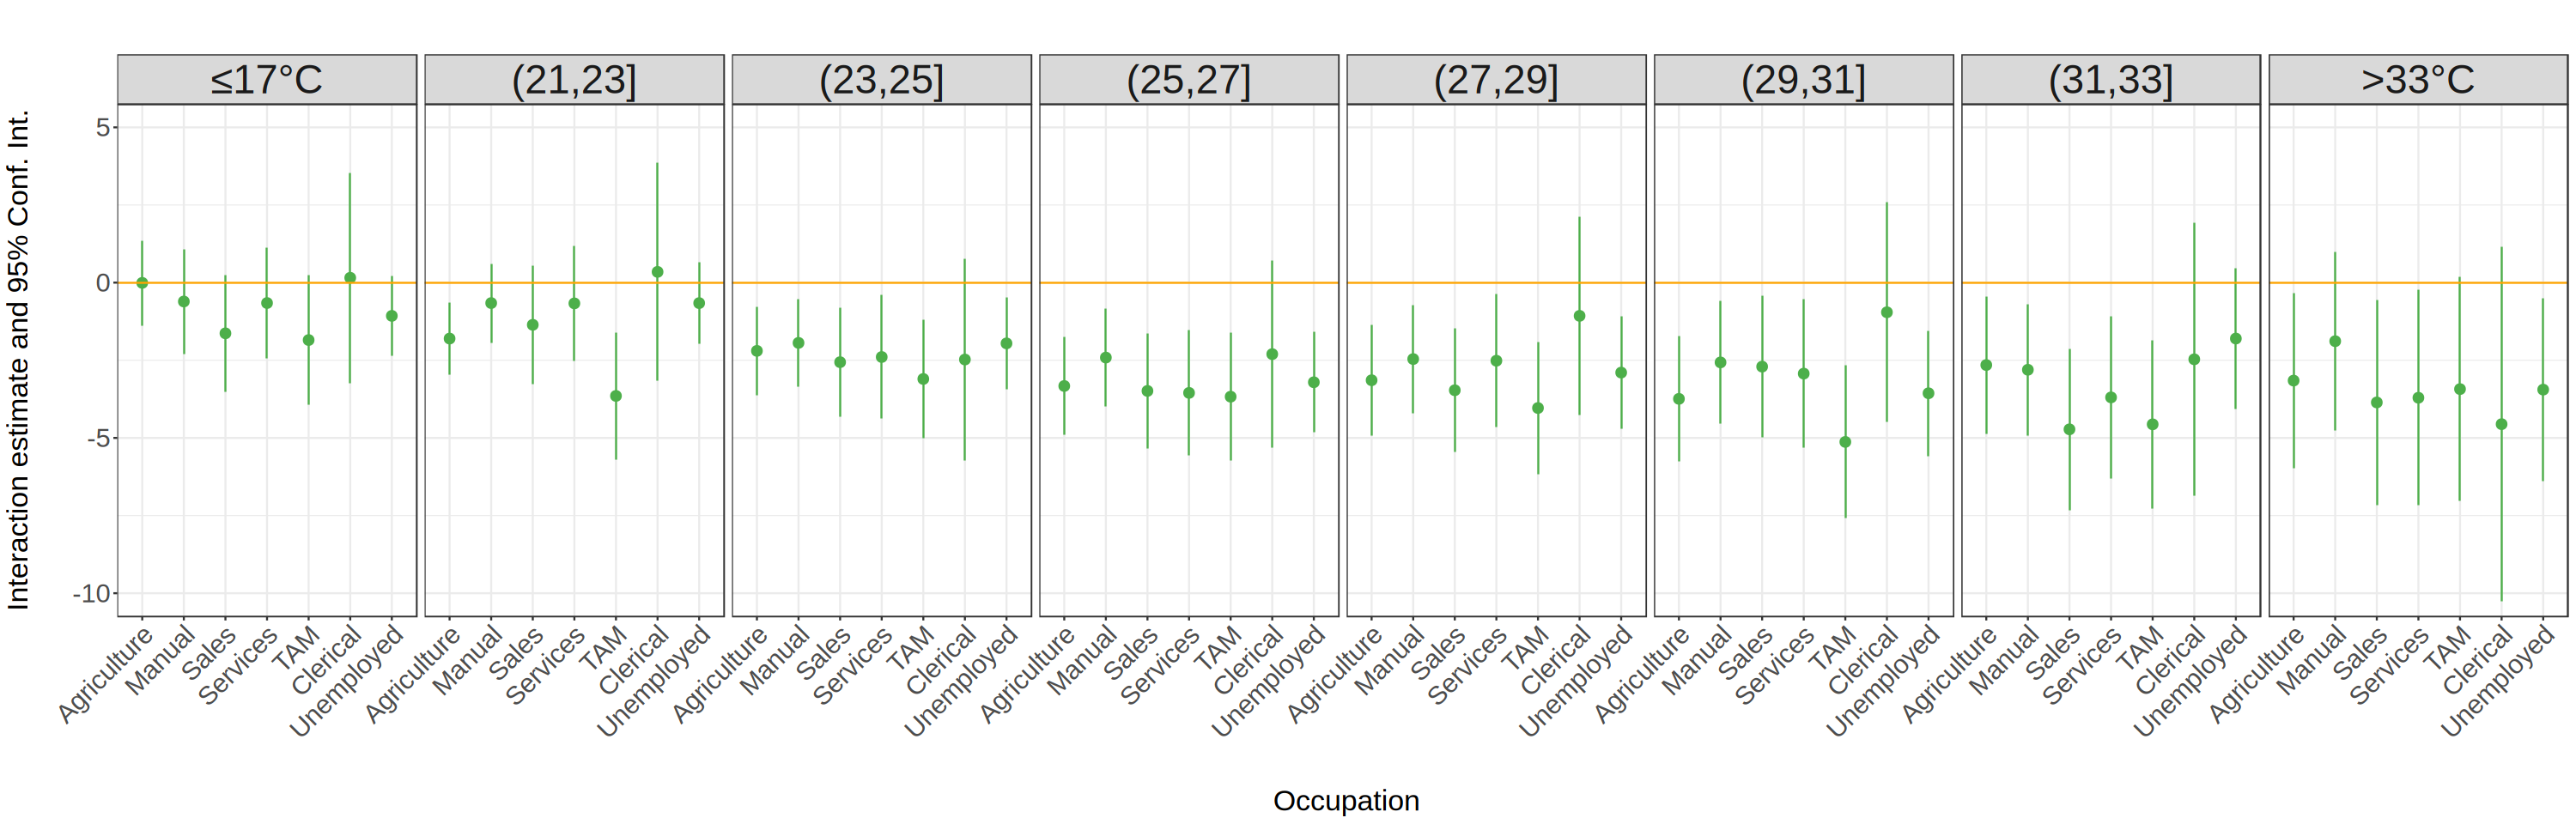

In [13]:
options(repr.plot.width=25, repr.plot.height=8, scipen=9999)

plot_estimates <- ggplot(all_estimates,aes(x=occupation, y=estimate, ymin=conf.low, ymax=conf.high, color = group)) +
                          geom_pointrange(position = position_dodge(width = 1/4)) +
                          geom_hline(yintercept = 0, col = "orange") +
                          scale_x_discrete(labels = c("agri" = "Agriculture", 
                                                      "clerical" = "Clerical", 
                                                      "manual" = "Manual", 
                                                      "no_work" = "Unemployed",
                                                      "prof_tech_manag"="TAM",
                                                      "sales"="Sales",
                                                      "services"="Services"))+
                          labs(title ="",
                               x="\n Occupation", 
                               y="Interaction estimate and 95% Conf. Int.\n", 
                               color="Group")+
                          scale_color_manual(values = c('#4DAF4A','#377EB8'),#3 of viridis(4),
                                             na.value="white")+
                          coord_cartesian(y=c(-10,5))+
                          facet_grid(cols = vars(Tbin), 
                                     labeller=as_labeller(setNames(T_bins_labels_pretty,T_bins_labels)))+
                          theme_bw() +
                          theme_perso()
plot_estimates

In [14]:
ggsave("./3_output/img/hetero_men_occup_hemo.png", width=25, height=8, plot_estimates)